<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Juan Esteban Barrantes Riaño
- Juan Camilo Ordoñez Valenzuela
- Daniel Alejandro Caicedo Ballen

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [2]:
### TU CÓDIGO AQUÍ ###
# Importación de librerías estándar
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de modelos y métricas de Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.csv'.

In [4]:
### TU CÓDIGO AQUÍ ###
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
path = '/content/drive/MyDrive/datasets'

In [7]:
os.chdir(path)

In [8]:
df = pd.read_csv('Country-data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970
163,Venezuela,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500
164,Vietnam,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310
165,Yemen,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310


2. Muestra las 5 primeras filas

In [9]:
print("Primeras filas:")
### TU CÓDIGO AQUÍ ###
df.head()

Primeras filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [10]:
print("\nInformación del DataFrame:")
### TU CÓDIGO AQUÍ ###
df.info()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


4. Obtén las estadísticas descriptivas de las variables del dataset

In [11]:
print("\nEstadísticas Descriptivas:")
### TU CÓDIGO AQUÍ ###
df.describe()


Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


5. ¿Hay valores nulos?

In [12]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


6. ¿Las escalas de las variables son muy diferentes?

Sí, las escalas de las variables en este dataset son muy diferentes. Al observar las estadísticas descriptivas, se nota que variables como el ingreso (income) y el PIB per cápita (gdpp) tienen valores mucho más altos, con medias alrededor de 17.145 y 12.964 respectivamente, y pueden llegar hasta 125.000 y 105.000. En cambio, otras variables como la mortalidad infantil (child_mort), las exportaciones (exports), el gasto en salud (health) o la tasa de fertilidad (total_fer) presentan valores mucho más pequeños, con medias entre 2.95 y 41.11 aproximadamente. Esta gran diferencia en las magnitudes de las variables hace que no todas estén en la misma escala.

7. ¿Qué implicaciones tiene esto para el análisis de clustering?


Esta diferencia en las escalas tiene implicaciones importantes para el análisis de clustering. En algoritmos como K-Means, que se basan en el cálculo de distancias entre los puntos, las variables con valores más grandes (como income y gdpp) dominarán el resultado. Esto significa que el clustering se realizará principalmente según el nivel de riqueza de los países, mientras que otras variables relevantes como la mortalidad infantil, la esperanza de vida o el gasto en salud tendrán muy poco peso en la formación de los grupos. Como consecuencia, los clusters obtenidos pueden ser sesgados y no reflejar correctamente las similitudes reales entre los países en todas las dimensiones del dataset.

8. Redacta un análisis de las estadísticas descriptivas

El dataset contiene 167 países y 10 variables, todas completas sin valores nulos. Las estadísticas descriptivas muestran una gran variabilidad entre las variables. La mortalidad infantil (child_mort) tiene una media de 38.27 con un rango amplio que va desde 2.6 hasta 208, lo que refleja fuertes desigualdades en salud. El ingreso (income) presenta una media de 17.145 dólares y el PIB per cápita (gdpp) una media de 12.964 dólares, ambos con desviaciones estándar muy altas y rangos extremos que llegan hasta 125.000 y 105.000 respectivamente. Por su parte, la esperanza de vida (life_expec) promedia 70.56 años, mientras que la tasa de fertilidad (total_fer) se sitúa en 2.95 hijos por mujer. Variables como exports, imports y health muestran valores más moderados, pero también con dispersiones notables.
En general, las estadísticas revelan una alta heterogeneidad en el dataset, especialmente en los indicadores económicos y de salud. Esta gran diferencia en las escalas y en la dispersión de los datos indica la presencia de países muy desarrollados junto a otros en condiciones mucho más precarias. La elevada variabilidad observada, particularmente en income, gdpp y child_mort, resalta la importancia de estandarizar las variables antes de aplicar técnicas de análisis multivariado como el clustering, ya que las diferencias de magnitud podrían sesgar los resultados si no se tratan adecuadamente.

## Ejercicio 3: Preprocesamiento de Datos

1. Selecciona solo las variables numéricas para el clustering

In [13]:

X=df[["child_mort", "exports", "health", "imports",	"income",	"inflation",	"life_expec",	"total_fer",	"gdpp"]]

2. Estandariza las variables usando StandardScaler

In [14]:
#Estandarizando las caracteristicas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#Conversion del dataframe
X_scaled_df = pd.DataFrame(X_scaled, columns=["child_mort", "exports", "health", "imports",	"income",	"inflation",	"life_expec",	"total_fer",	"gdpp"])
X_scaled_df


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04
...,...,...,...,...,...,...,...,...,...
162,-0.23,0.20,-0.57,0.24,-0.74,-0.49,-0.85,0.37,-0.55
163,-0.53,-0.46,-0.70,-1.21,-0.03,3.62,0.55,-0.32,0.03
164,-0.37,1.13,0.01,1.38,-0.66,0.41,0.29,-0.66,-0.64
165,0.45,-0.41,-0.60,-0.52,-0.66,1.50,-0.34,1.14,-0.64


## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.

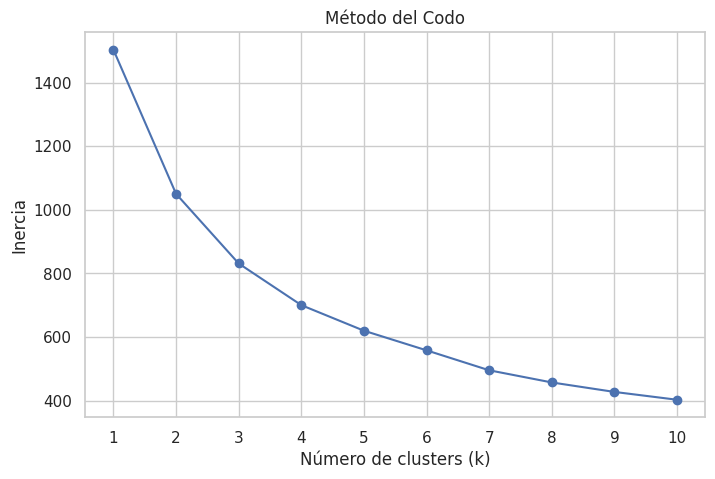

In [25]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

3. Calcula y grafica el coeficiente de silueta

Para n_clusters = 2, el coeficiente de silueta promedio es: 0.2874
Para n_clusters = 3, el coeficiente de silueta promedio es: 0.2833
Para n_clusters = 4, el coeficiente de silueta promedio es: 0.2960
Para n_clusters = 5, el coeficiente de silueta promedio es: 0.2993
Para n_clusters = 6, el coeficiente de silueta promedio es: 0.2287
Para n_clusters = 7, el coeficiente de silueta promedio es: 0.2477
Para n_clusters = 8, el coeficiente de silueta promedio es: 0.2388
Para n_clusters = 9, el coeficiente de silueta promedio es: 0.2073
Para n_clusters = 10, el coeficiente de silueta promedio es: 0.2022


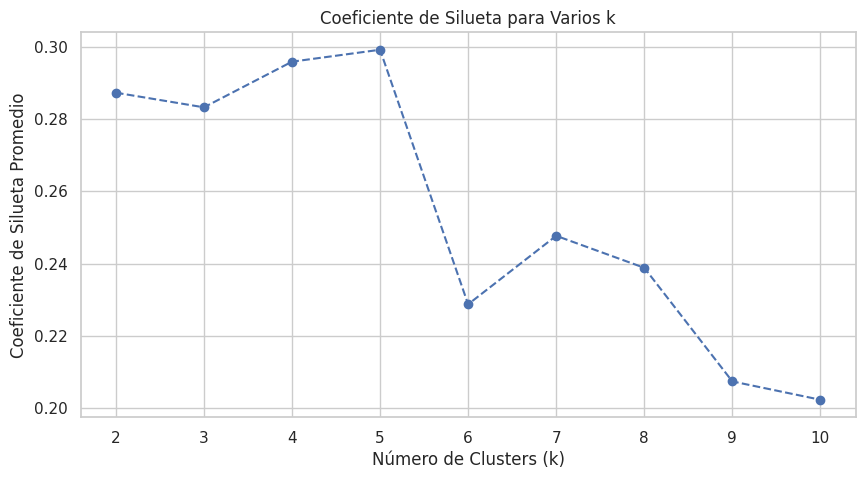

In [27]:
range_n_clusters = range(2, 11)
silhouette_avg_scores = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled_df)
    silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)
    print(f"Para n_clusters = {n_clusters}, el coeficiente de silueta promedio es: {silhouette_avg:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o', linestyle='--')
plt.title('Coeficiente de Silueta para Varios k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.show()

4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.

Según el coeficiente de silueta, el número de clusters más adecuado es k = 5. Este valor presenta el coeficiente de silueta promedio más alto de todos los evaluados (0.2993). El coeficiente de silueta mide qué tan bien separados y cohesionados están los clusters; un valor más alto indica que los países dentro de cada grupo son más similares entre sí y más diferentes a los de otros grupos. Aunque k=4 también tiene un valor cercano (0.2960), k=5 es ligeramente superior, por lo que se considera la mejor opción según esta métrica.

5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.

Basándonos en ambos métodos, la decisión más razonable es utilizar k = 5 clusters. El método del codo muestra una disminución fuerte y continua de la inercia hasta aproximadamente k=4 o k=5, donde la curva comienza a aplanarse, indicando que agregar más clusters ya no reduce la inercia de forma tan significativa. Por su parte, el coeficiente de silueta alcanza su punto máximo precisamente en k=5 (0.2993), superando a los demás valores evaluados.
Combinando ambas técnicas, k=5 representa un buen equilibrio: ofrece una reducción importante de la inercia (según el codo) y la mejor separación y cohesión de los grupos (según la silueta). Elegir k=4 también sería aceptable, pero k=5 resulta ligeramente superior en la métrica de silueta sin perder la interpretación del codo.

6. Aplica K-Means con el k que tu grupo eligió.

In [28]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled_df)
clusters_kmeans

array([1, 0, 0, 1, 0, 0, 0, 3, 3, 0, 3, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 1,
       0, 3, 0, 1, 1, 0, 1, 3, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 3, 3,
       3, 0, 0, 0, 0, 1, 1, 0, 0, 3, 3, 1, 1, 0, 3, 1, 3, 0, 0, 1, 1, 0,
       1, 0, 3, 0, 0, 0, 1, 3, 3, 3, 0, 3, 0, 0, 1, 1, 3, 0, 1, 0, 0, 1,
       1, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       3, 3, 1, 4, 3, 0, 1, 0, 0, 0, 0, 0, 3, 3, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 2, 0, 3, 1, 1, 3, 3, 0, 0, 1, 0, 3, 3, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 3, 3, 3, 0, 0, 0, 0, 0, 1, 1], dtype=int32)

7. Añade la asignación de clusters al DataFrame original

In [29]:
df['Cluster_KMeans'] = clusters_kmeans
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_KMeans
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,1
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,0
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,0
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,1
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970,0
163,Venezuela,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500,0
164,Vietnam,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310,0
165,Yemen,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310,1


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [40]:
### TU CÓDIGO AQUÍ ###
cluster_profile = df.groupby('Cluster_KMeans').mean(numeric_only=True).round(2)
print("Perfil de los clusters:")
cluster_profile

Perfil de los clusters:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster_KMeans,,,,,,,,,
0,21.61,40.98,6.17,47.52,"12,801.07",7.62,73.00,2.28,"6,581.81"
1,90.79,29.66,6.46,43.68,"3,870.70",9.95,59.21,4.97,"1,900.26"
2,4.13,176.00,6.79,156.67,"64,033.33",2.47,81.43,1.38,"57,566.67"
3,5.18,46.12,9.09,40.58,"44,021.88",2.51,80.08,1.79,"42,118.75"
4,130.00,25.30,5.07,17.40,"5,150.00",104.00,60.50,5.84,"2,330.00"


2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

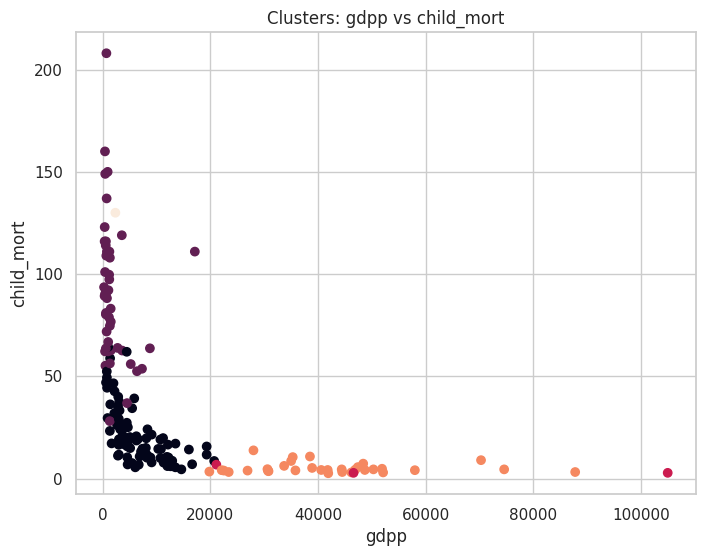

In [41]:
### TU CÓDIGO AQUÍ ###
plt.figure(figsize=(8,6))

plt.scatter(df['gdpp'], df['child_mort'], c=df['Cluster_KMeans'])

plt.xlabel('gdpp')
plt.ylabel('child_mort')
plt.title('Clusters: gdpp vs child_mort')

plt.show()

3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo.


Cluster 0: Países en Desarrollo Medio

Cluster 1: Países con Alto Riesgo Social y Bajo Desarrollo

Cluster 2: Países Muy Desarrollados y Abiertos al Comercio

Cluster 3: Países Ricos con Alto Bienestar

Cluster 4: Países en Crisis Extrema

4. **Describe cada cluster:** Para cada grupo, describe sus características principales.


El Cluster 0 agrupa países de desarrollo medio. Presentan mortalidad infantil moderada (21.6), ingreso per cápita cercano a los 12,800 dólares y PIB per cápita de aproximadamente 6,582 dólares. Tienen una esperanza de vida razonable (73 años) y niveles moderados de exportaciones e importaciones. Representan la mayoría de los países emergentes estables.
El Cluster 1 está formado por países con alto riesgo social y bajo desarrollo económico. Destacan por su muy alta mortalidad infantil (90.8), bajo ingreso (3,871 dólares) y bajo PIB per cápita (1,900 dólares). Su esperanza de vida es la más baja (59.2 años) y tienen una alta tasa de fertilidad (4.97), lo que refleja condiciones de pobreza y precariedad social.
El Cluster 2 corresponde a países muy desarrollados y altamente abiertos al comercio. Tienen mortalidad infantil muy baja (4.1), ingresos extremadamente altos (64,033 dólares) y el PIB per cápita más elevado del dataset (57,567 dólares). Sus exportaciones e importaciones son muy altas (176% y 157% del PIB respectivamente), típicas de economías pequeñas y muy integradas al mercado global.
El Cluster 3 reúne países ricos con alto bienestar. Muestran mortalidad infantil baja (5.2), altos ingresos (44,022 dólares) y alto PIB per cápita (42,119 dólares). Destacan por su excelente esperanza de vida (80 años) y niveles moderados de comercio exterior.
El Cluster 4 es el más crítico. Incluye países con mortalidad infantil extremadamente alta (130), muy bajo ingreso (5,150 dólares), bajo PIB per cápita (2,330 dólares) y la inflación más alta del dataset (104%). Su esperanza de vida es baja (60.5 años), lo que indica situaciones de crisis humanitaria y económica severa.

5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.

Para la recomendación de política pública, se selecciona el Cluster 1 (Países con Alto Riesgo Social y Bajo Desarrollo). Estos países se caracterizan por presentar la mortalidad infantil más alta (90.8), bajos niveles de ingreso (aproximadamente 3.871 dólares) y PIB per cápita (1.900 dólares), junto con una esperanza de vida reducida (59.2 años) y una alta tasa de fertilidad (4.97). Esta combinación refleja condiciones de pobreza estructural y vulnerabilidad social que requieren intervención prioritaria.
El PNUD podría implementar un Programa Integral de Reducción de la Mortalidad Infantil y Fortalecimiento de Capacidades Básicas. Este programa debería incluir inversiones en salud materno-infantil, capacitación de personal sanitario, campañas de vacunación masiva, programas de planificación familiar y empoderamiento femenino, así como iniciativas de generación de ingresos básicos mediante microfinanzas y apoyo al empleo juvenil. De esta forma se atacarían las causas raíz de la vulnerabilidad y se mejorarían de manera sostenida los indicadores sociales más críticos de estos países.